In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
sample = pd.read_csv("diabetes.csv")
sample

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
sample.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [6]:
sample.sum()

,0
Pregnancies,2953.000
Glucose,92847.000
BloodPressure,53073.000
SkinThickness,15772.000
Insulin,61286.000
BMI,24570.300
DiabetesPedigreeFunction,362.401
Age,25529.000
Outcome,268.000


In [7]:
sample.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

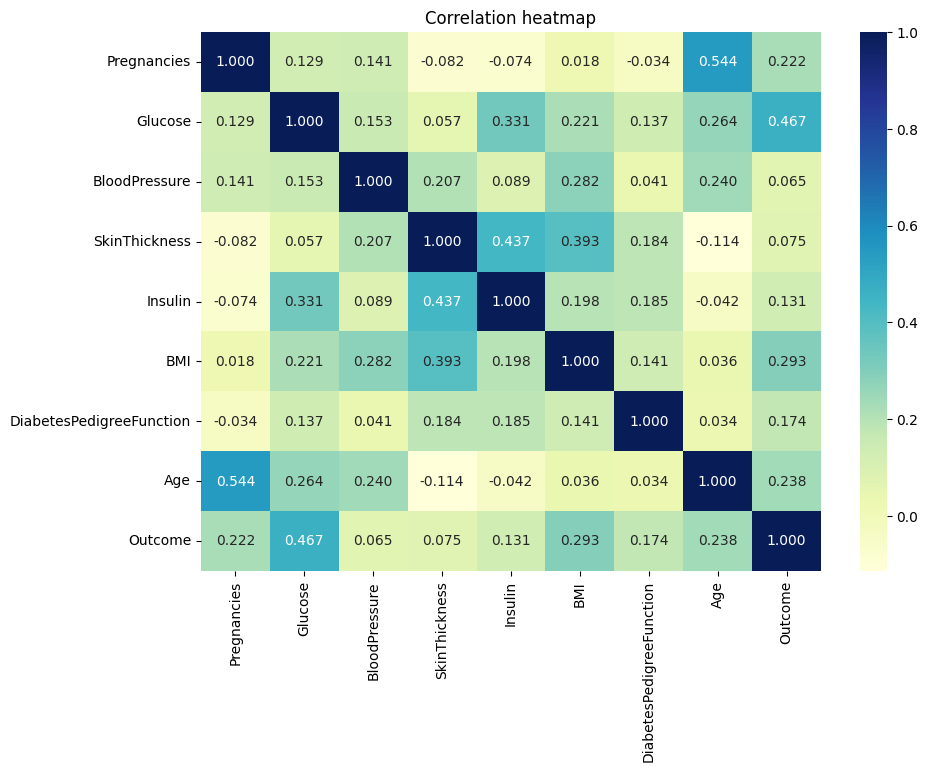

In [8]:
plt.figure(figsize=(10,7))
sns.heatmap(sample.corr(), annot = True, fmt=".3f", cmap ="YlGnBu")
plt.title("Correlation heatmap")

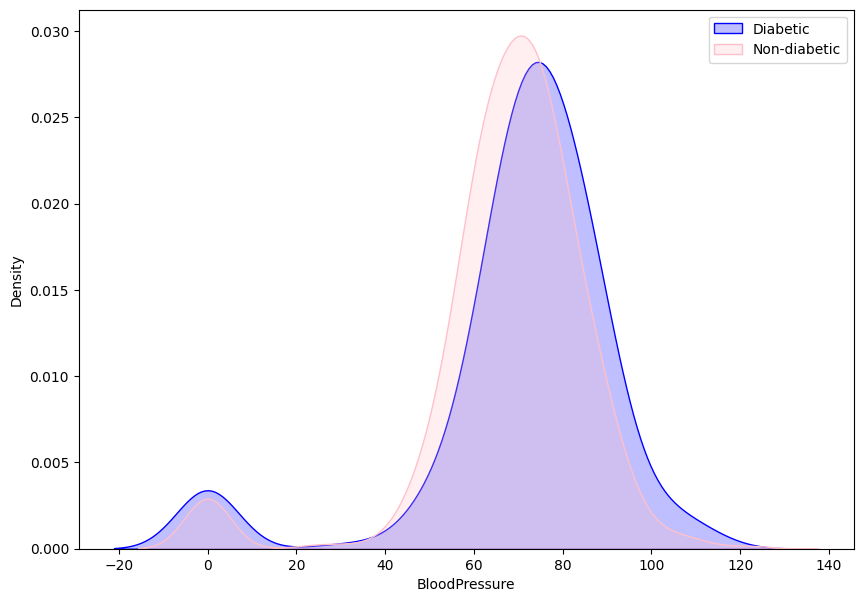

In [9]:
plt.figure(figsize=(10,7))
kde = sns.kdeplot(sample["BloodPressure"][sample["Outcome"]==1], color = "Blue" , fill = True)
kde = sns.kdeplot(sample["BloodPressure"][sample["Outcome"]==0], color = "Pink" , fill = True)
kde.set_xlabel("BloodPressure")
kde.set_ylabel("Density")
kde.legend(["Diabetic", "Non-diabetic"])

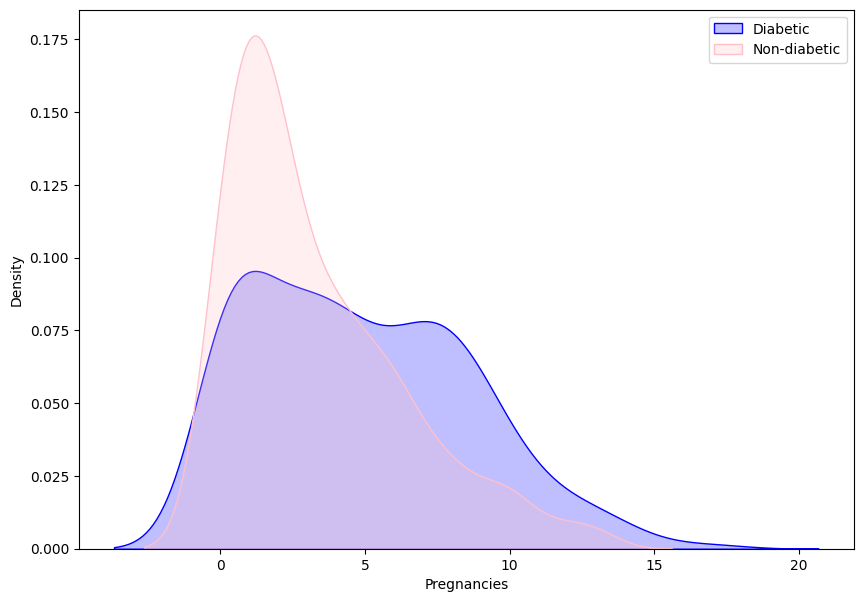

In [10]:
plt.figure(figsize=(10,7))
kde = sns.kdeplot(sample["Pregnancies"][sample["Outcome"]==1], color = "Blue" , fill = True)
kde = sns.kdeplot(sample["Pregnancies"][sample["Outcome"]==0], color = "Pink" , fill = True)
kde.set_xlabel("Pregnancies")
kde.set_ylabel("Density")
kde.legend(["Diabetic", "Non-diabetic"])

<Axes: xlabel='Outcome', ylabel='Glucose'>

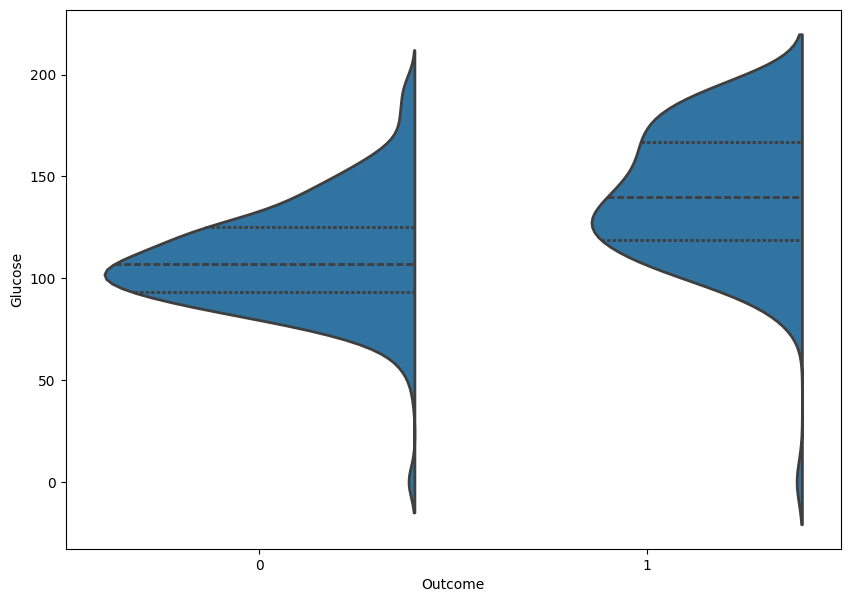

In [11]:
plt.figure(figsize=(10,7))
sns.violinplot(data=sample,x="Outcome", y="Glucose", split= True, linewidth=2, inner = "quart")

In [12]:
sample["Glucose"] = sample["Glucose"].replace(0, sample["Glucose"].median())
sample["BloodPressure"] = sample["BloodPressure"].replace(0, sample["BloodPressure"].median())
sample["SkinThickness"] = sample["SkinThickness"].replace(0, sample["SkinThickness"].mean())
sample["Insulin"] = sample["Insulin"].replace(0, sample["Insulin"].mean())
sample["BMI"] = sample["BMI"].replace(0, sample["BMI"].mean())

In [13]:
X = sample.drop(["Outcome"],axis = 1)
y = sample["Outcome"]

In [14]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35.000000,79.799479,33.6,0.627,50
1,1,85,66,29.000000,79.799479,26.6,0.351,31
2,8,183,64,20.536458,79.799479,23.3,0.672,32
3,1,89,66,23.000000,94.000000,28.1,0.167,21
4,0,137,40,35.000000,168.000000,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48.000000,180.000000,32.9,0.171,63
764,2,122,70,27.000000,79.799479,36.8,0.340,27
765,5,121,72,23.000000,112.000000,26.2,0.245,30
766,1,126,60,20.536458,79.799479,30.1,0.349,47


In [15]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.22,random_state=42)

In [17]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
131,9,122,56,20.536458,79.799479,33.3,1.114,33
44,7,159,64,20.536458,79.799479,27.4,0.294,40
70,2,100,66,20.000000,90.000000,32.9,0.867,28
264,4,123,62,20.536458,79.799479,32.0,0.226,35
673,3,123,100,35.000000,240.000000,57.3,0.880,22
...,...,...,...,...,...,...,...,...
71,5,139,64,35.000000,140.000000,28.6,0.411,26
106,1,96,122,20.536458,79.799479,22.4,0.207,27
270,10,101,86,37.000000,79.799479,45.6,1.136,38
435,0,141,72,20.536458,79.799479,42.4,0.205,29


In [18]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
668,6,98,58,33.000000,190.000000,34.0,0.430,43
324,2,112,75,32.000000,79.799479,35.7,0.148,21
624,2,108,64,20.536458,79.799479,30.8,0.158,21
690,8,107,80,20.536458,79.799479,24.6,0.856,34
473,7,136,90,20.536458,79.799479,29.9,0.210,50
...,...,...,...,...,...,...,...,...
377,1,87,60,37.000000,75.000000,37.2,0.509,22
235,4,171,72,20.536458,79.799479,43.6,0.479,26
158,2,88,74,19.000000,53.000000,29.0,0.229,22
69,4,146,85,27.000000,100.000000,28.9,0.189,27


In [19]:
y_train

,Outcome
131,1
44,0
70,1
264,1
673,0
...,...
71,0
106,0
270,1
435,1


In [20]:
y_test

,Outcome
668,0
324,0
624,0
690,0
473,0
...,...
377,0
235,1
158,0
69,0


In [21]:
from sklearn.neighbors import KNeighborsClassifier
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.22,random_state=42)

In [22]:
training_accuracy = []
testing_accuracy = []
for n_neighbours in range(1,10):
  knn = KNeighborsClassifier(n_neighbors=n_neighbours)
  knn.fit(X_train, y_train)
  training_accuracy.append(knn.score(X_train, y_train))
  testing_accuracy.append(knn.score(X_test, y_test))

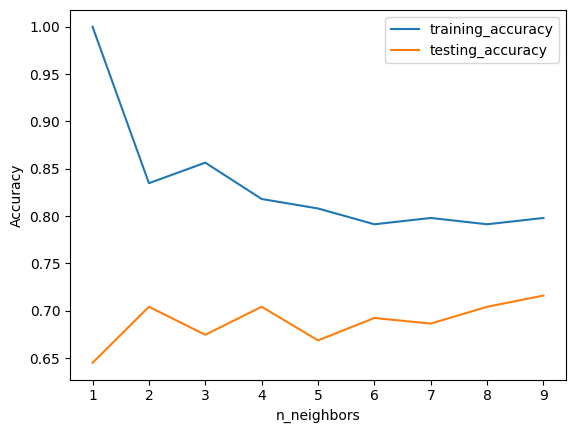

In [23]:
plt.plot(range(1,10), training_accuracy, label = "training_accuracy")
plt.plot(range(1,10), testing_accuracy, label = "testing_accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.show()

In [24]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train), ": training accuracy")
print(knn.score(X_test, y_test), ": testing accuracy")

0.7979966611018364 : training accuracy
0.7159763313609467 : testing accuracy


In [25]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train), ": training accuracy")
print(tree.score(X_test, y_test), ": testing accuracy")

1.0 : training accuracy
0.6923076923076923 : testing accuracy


In [26]:
tree1 = DecisionTreeClassifier(random_state=0, max_depth=4)
tree1.fit(X_train, y_train)
print(tree1.score(X_train, y_train), ": training accuracy")
print(tree1.score(X_test, y_test), ": testing accuracy")

0.8030050083472454 : training accuracy
0.7159763313609467 : testing accuracy


In [27]:
from sklearn.neural_network import MLPClassifier
mlpc = DecisionTreeClassifier(random_state=42)
mlpc.fit(X_train, y_train)
print(mlpc.score(X_train, y_train), ": Training accuracy")
print(mlpc.score(X_test, y_test), ": Testing accuracy")

1.0 : Training accuracy
0.7159763313609467 : Testing accuracy


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [29]:
mlpc1 = MLPClassifier(random_state=42)
mlpc1.fit(X_train, y_train)
print(mlpc1.score(X_train, y_train), ": Training accuracy")
print(mlpc1.score(X_test, y_test), ": Testing accuracy")

0.7178631051752922 : Training accuracy
0.6686390532544378 : Testing accuracy
